### Import the libraries and Load the dataset

In [293]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_sales =pd.read_csv("/content/drive/MyDrive/Ironhack/sales.csv")
df_sales.head()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


### Exploratory Data Analysis (EDA)

In [294]:
df_sales.shape

(640840, 10)

In [295]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Unnamed: 0           640840 non-null  int64 
 1   store_ID             640840 non-null  int64 
 2   day_of_week          640840 non-null  int64 
 3   date                 640840 non-null  object
 4   nb_customers_on_day  640840 non-null  int64 
 5   open                 640840 non-null  int64 
 6   promotion            640840 non-null  int64 
 7   state_holiday        640840 non-null  object
 8   school_holiday       640840 non-null  int64 
 9   sales                640840 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 48.9+ MB


In [296]:
df_sales.isnull().sum()

,0
Unnamed: 0,0
store_ID,0
day_of_week,0
date,0
nb_customers_on_day,0
open,0
promotion,0
state_holiday,0
school_holiday,0
sales,0


In [297]:
df_sales['date']=pd.to_datetime(df_sales['date'])

In [298]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Unnamed: 0           640840 non-null  int64         
 1   store_ID             640840 non-null  int64         
 2   day_of_week          640840 non-null  int64         
 3   date                 640840 non-null  datetime64[ns]
 4   nb_customers_on_day  640840 non-null  int64         
 5   open                 640840 non-null  int64         
 6   promotion            640840 non-null  int64         
 7   state_holiday        640840 non-null  object        
 8   school_holiday       640840 non-null  int64         
 9   sales                640840 non-null  int64         
dtypes: datetime64[ns](1), int64(8), object(1)
memory usage: 48.9+ MB


In [299]:
df_sales['state_holiday'].value_counts()

,count
state_holiday,
0,621160
a,12842
b,4214
c,2624


In [300]:
df_sales = df_sales.drop(columns=['Unnamed: 0', 'date' ], axis=1)

In [301]:
df_sales.head()

,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,366,4,517,1,0,0,0,4422
1,394,6,694,1,0,0,0,8297
2,807,4,970,1,1,0,0,9729
3,802,2,473,1,1,0,0,6513
4,726,4,1068,1,1,0,0,10882


In [302]:
df_sales.describe().T

,count,mean,std,min,25%,50%,75%,max
store_ID,640840.0,558.211348,321.878521,1.0,280.0,558.0,837.0,1115.0
day_of_week,640840.0,4.000189,1.996478,1.0,2.0,4.0,6.0,7.0
nb_customers_on_day,640840.0,633.398577,464.094416,0.0,405.0,609.0,838.0,5458.0
open,640840.0,0.830185,0.375470,0.0,1.0,1.0,1.0,1.0
promotion,640840.0,0.381718,0.485808,0.0,0.0,0.0,1.0,1.0
school_holiday,640840.0,0.178472,0.382910,0.0,0.0,0.0,0.0,1.0
sales,640840.0,5777.469011,3851.338083,0.0,3731.0,5746.0,7860.0,41551.0


In [303]:
df_sales['store_ID'].value_counts()

,count
store_ID,
1045,645
309,636
754,635
432,634
286,634
...,...
287,448
1004,448
1065,445


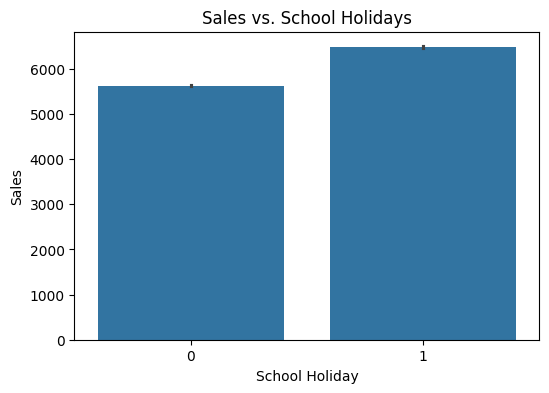

In [304]:
plt.figure(figsize=(6,4))

sns.barplot(data =df_sales, x='school_holiday', y ='sales')
plt.title("Sales vs. School Holidays")
plt.xlabel("School Holiday")
plt.ylabel("Sales")
plt.show()

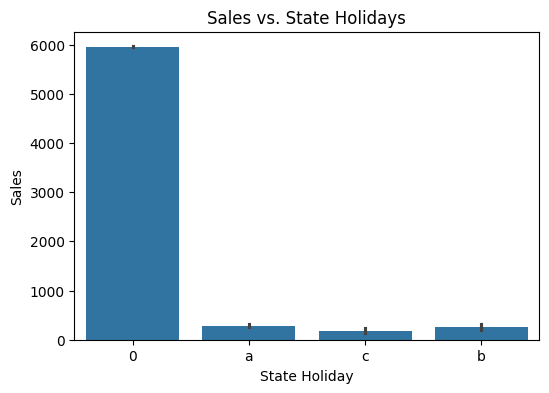

In [305]:
plt.figure(figsize=(6,4))

sns.barplot(data =df_sales, x='state_holiday', y ='sales')
plt.title("Sales vs. State Holidays")
plt.xlabel("State Holiday")
plt.ylabel("Sales")
plt.show()

In [306]:
df_sales.nunique()

,0
store_ID,1115
day_of_week,7
nb_customers_on_day,3886
open,2
promotion,2
state_holiday,4
school_holiday,2
sales,20129


In [307]:
df_sales['school_holiday'].value_counts()

,count
school_holiday,
0,526468
1,114372


### Sales Vs. Store ID

In [308]:
df_sales.groupby("store_ID")['sales'].sum()

,sales
store_ID,
1,2418077
2,2493044
3,3443248
4,4624267
5,2283572
...,...
1111,2607237
1112,4950139
1113,3288394


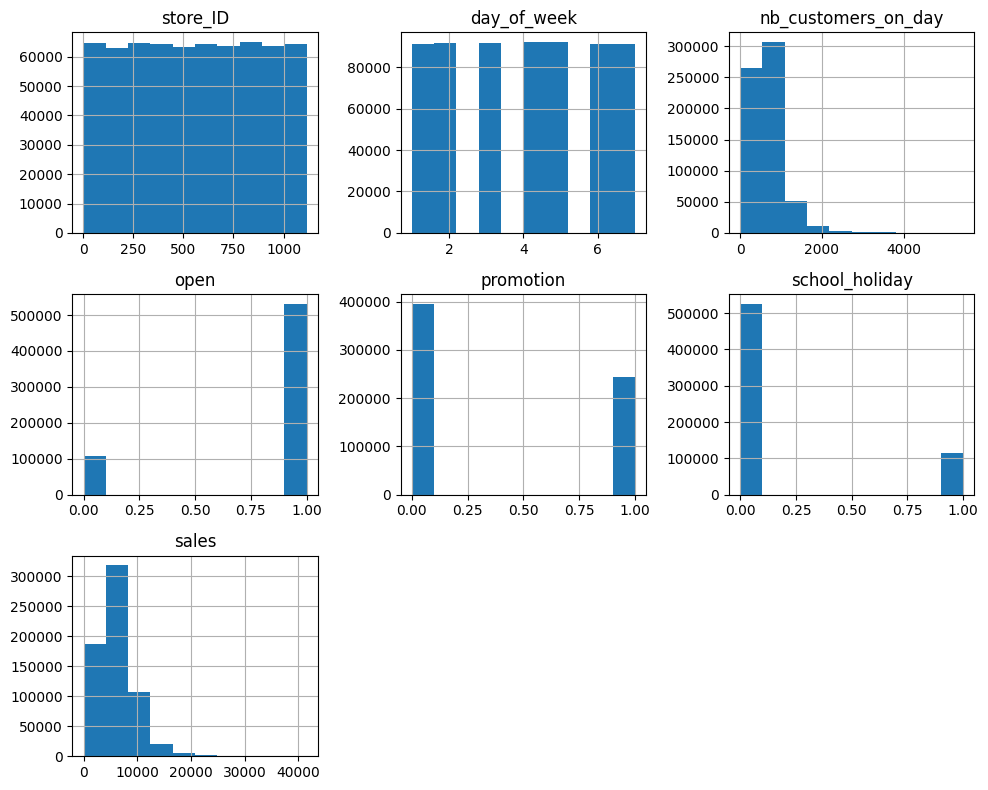

In [309]:
numerical_columns = df_sales.select_dtypes(include=['int64', 'float64']).columns
df_sales[numerical_columns].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

### Split the data 80% as Training Data and 20% as Testing data

In [310]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

X = df_sales.drop('sales', axis=1)
y = df_sales['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

encoder = OneHotEncoder(drop='first', handle_unknown='ignore')

X_train_cat = encoder.fit_transform(X_train[['state_holiday']])
X_test_cat = encoder.transform(X_test[['state_holiday']])

In [311]:
encoded_cols = encoder.get_feature_names_out(['state_holiday'])

In [312]:
X_train_cat = pd.DataFrame(X_train_cat.toarray(), columns=encoded_cols, index=X_train.index)

In [313]:
X_test_cat = pd.DataFrame(X_test_cat.toarray(), columns=encoded_cols, index=X_test.index)

In [314]:
print(X_train_cat)

        state_holiday_a  state_holiday_b  state_holiday_c
360184              0.0              0.0              0.0
162306              0.0              0.0              0.0
80802               0.0              0.0              0.0
607893              0.0              0.0              0.0
606656              0.0              0.0              0.0
...                 ...              ...              ...
110268              0.0              0.0              0.0
259178              0.0              0.0              0.0
365838              1.0              0.0              0.0
131932              0.0              1.0              0.0
121958              0.0              0.0              0.0

[512672 rows x 3 columns]


In [315]:
print(X_test_cat)

        state_holiday_a  state_holiday_b  state_holiday_c
360263              0.0              0.0              0.0
226238              0.0              0.0              0.0
94660               0.0              0.0              0.0
322601              0.0              0.0              0.0
450235              0.0              0.0              0.0
...                 ...              ...              ...
186704              0.0              0.0              0.0
125769              0.0              0.0              0.0
550039              0.0              0.0              0.0
609029              0.0              0.0              0.0
548298              0.0              0.0              0.0

[128168 rows x 3 columns]


In [316]:
X_train_num = X_train.drop('state_holiday', axis=1)

In [317]:
X_test_num = X_test.drop('state_holiday', axis=1)


In [318]:

X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)

In [319]:
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

### Apply StandardScaler

In [320]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

In [321]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()



In [322]:
model.fit(X_train_scaled, y_train)

LinearRegression()

### Prediction on training data

In [323]:
y_train_pred = model.predict(X_train_scaled)
y_train_pred

array([7239.660973  , 8588.50840083, 8903.91330412, ..., -568.47447718,
        491.34083363, 5114.08335112])

In [324]:
from sklearn.metrics import mean_squared_error, r2_score

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))

Train RMSE: 1473.40138206195


In [325]:
print("Train R²:", r2_score(y_train, y_train_pred))

Train R²: 0.8537668432677094


### Prediction on Testing data

In [326]:
y_test_pred = model.predict(X_test_scaled)
y_test_pred


array([9680.94794765,  -48.24126599, 5269.55580863, ..., 9684.42162673,
       8850.67235   , 7679.94853731])

In [327]:
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Test RMSE: 1483.556250478723


In [328]:
print("Test R²:", r2_score(y_test, y_test_pred))

Test R²: 0.8511033976586159


### Linear Regression with Train–Validation–Test Split (70%–15%–15%)

In [329]:

df =pd.read_csv("/content/drive/MyDrive/Ironhack/sales.csv")
df.head()

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [330]:


X = df.drop('sales', axis=1)
y = df['sales']

In [331]:
df = df.drop(columns=['Unnamed: 0', 'date' ], axis=1)


In [332]:
X = df.drop('sales', axis=1)
y = df['sales']

In [333]:
### 1st Split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

In [334]:
### 2nd Split
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

### One-Hot Encode the Categorical Column

In [335]:
encoder = OneHotEncoder(
    drop='first',
    handle_unknown='ignore'
)

X_train_cat = encoder.fit_transform(
    X_train[['state_holiday']]
)

X_val_cat = encoder.transform(
    X_val[['state_holiday']]
)

X_test_cat = encoder.transform(
    X_test[['state_holiday']]
)

In [336]:
encoded_cols = encoder.get_feature_names_out(
    ['state_holiday']
)

X_train_cat = pd.DataFrame(
    X_train_cat.toarray(),
    columns=encoded_cols,
    index=X_train.index
)

X_val_cat = pd.DataFrame(
    X_val_cat.toarray(),
    columns=encoded_cols,
    index=X_val.index
)

X_test_cat = pd.DataFrame(
    X_test_cat.toarray(),
    columns=encoded_cols,
    index=X_test.index
)

In [337]:
X_train_num = X_train.drop(
    'state_holiday',
    axis=1
)

X_val_num = X_val.drop(
    'state_holiday',
    axis=1
)

X_test_num = X_test.drop(
    'state_holiday',
    axis=1
)

In [338]:
X_train_final = pd.concat(
    [X_train_num, X_train_cat],
    axis=1
)

X_val_final = pd.concat(
    [X_val_num, X_val_cat],
    axis=1
)

X_test_final = pd.concat(
    [X_test_num, X_test_cat],
    axis=1
)

### Apply Standard Scaler

In [339]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_final
)

X_val_scaled = scaler.transform(
    X_val_final
)

X_test_scaled = scaler.transform(
    X_test_final
)

In [340]:
lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

### On training set

In [341]:
y_train_pred_1 = lr.predict(
    X_train_scaled
)

y_train_pred_1

array([5828.79037457, 4735.73576106, 5728.20299323, ..., -567.58660554,
        489.22571434, 5115.1987743 ])

### Validation set

In [342]:
y_val_pred_1 = lr.predict(
    X_val_scaled
)

y_val_pred_1

array([5528.51926009,  -33.44722265, 5251.62847014, ..., 4974.49125178,
       6243.23925065, 5991.65203545])

### test set

In [343]:
y_test_pred_1 = lr.predict(
    X_test_scaled
)
y_test_pred_1

array([ -580.47447643, 11089.11590985,  7797.16974174, ...,
       13953.39506831,  5761.55877564,  5622.08073679])

### Evaluate the Model

### Training set

In [344]:
print(
    "Train R²:",
    r2_score(y_train, y_train_pred_1)
)

print(
    "Train RMSE:",
    np.sqrt(
        mean_squared_error(
            y_train,
            y_train_pred_1
        )
    )
)

Train R²: 0.8539064255516915
Train RMSE: 1472.6736282457418


### Validation Performance

In [345]:
print(
    "Validation R²:",
    r2_score(y_val, y_val_pred_1)
)

print(
    "Validation RMSE:",
    np.sqrt(
        mean_squared_error(
            y_val,
            y_val_pred_1
        )
    )
)

Validation R²: 0.8520791722645268
Validation RMSE: 1481.5241621302068


### Test performance

In [346]:
print(
    "Test R²:",
    r2_score(y_test, y_test_pred_1)
)

print(
    "Test RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            y_test_pred_1
        )
    )
)

Test R²: 0.8512560490184051
Test RMSE: 1482.1962864150967


### Random Forest

In [347]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf.fit(X_train_final, y_train)

RandomForestRegressor(max_depth=5, random_state=42)

In [348]:
y_train_pred = rf.predict(X_train_final)
y_val_pred = rf.predict(X_val_final)

In [349]:
y_train_pred

array([5.56982552e+03, 4.66709613e+03, 5.53516817e+03, ...,
       2.22985528e-04, 2.22985528e-04, 4.68425359e+03])

In [350]:
y_val_pred

array([5.53516817e+03, 2.22985528e-04, 5.53516817e+03, ...,
       4.66709613e+03, 5.61004966e+03, 5.61004966e+03])

In [351]:
y_test_pred = rf.predict(X_test_final)
y_test_pred

array([2.22985528e-04, 1.21721843e+04, 8.10166874e+03, ...,
       1.35303869e+04, 6.39540855e+03, 5.53516817e+03])

### For the Training Data

In [352]:
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Train R²:", r2_score(y_train, y_train_pred))


Train RMSE: 1428.5330290368095
Train R²: 0.8625329326731952


### For the validation data

In [353]:
print("Validation RMSE:",
      np.sqrt(mean_squared_error(y_val, y_val_pred)))

print("Validation R²:",
      r2_score(y_val, y_val_pred))

Validation RMSE: 1437.2484630341287
Validation R²: 0.8607883577978975


### For the Test data

In [354]:
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("Test R²:", r2_score(y_test, y_test_pred))

Test RMSE: 1439.574876855513
Test R²: 0.8596874914371304


###

XGBoost

In [355]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score


In [356]:
 xgb = XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )

xgb.fit(X_train_final, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

### For the Training data

In [357]:
 y_train_pred = xgb.predict(X_train_final)
 y_train_pred

array([5878.042   , 5156.919   , 5640.07    , ..., -115.767975,
       -101.19925 , 4905.1216  ], dtype=float32)

### For the validation data

In [358]:
 y_val_pred = xgb.predict(X_val_final)
 y_val_pred

array([5201.4976 ,   97.69016, 5260.2847 , ..., 4862.42   , 5573.228  ,
       5474.3057 ], dtype=float32)

### For the test data

In [359]:
y_test_pred = xgb.predict(X_test_final)
y_test_pred

array([  -25.343994,  9842.414   ,  7734.986   , ..., 12658.4375  ,
        6423.368   ,  5261.767   ], dtype=float32)

### Training Accuracy

In [360]:
print("Train RMSE:",
      np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Train R²:",
      r2_score(y_train, y_train_pred))

Train RMSE: 1203.727284313187
Train R²: 0.9023945331573486


### Validation Accuracy

In [361]:
print("Validation RMSE:",
      np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("Validation R²:",
      r2_score(y_val, y_val_pred))

Validation RMSE: 1206.9233612785858
Validation R²: 0.9018316864967346


### Test Accuracy

In [362]:
print("Test RMSE:",
      np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("Test R²:",
      r2_score(y_test, y_test_pred))

Test RMSE: 1214.557789897212
Test R²: 0.9001232981681824


### Based on the evaluation metrics, XGBoost is the best model for this sales prediction problem, followed by Random Forest and then Linear Regression. Therefore, XGBoost is recommended as the final model because it provides the highest predictive accuracy and the best generalization performance on unseen data.

###

### Predictions on new unseen data

In [363]:
new_data = pd.read_csv("/content/REAL_DATA.csv")
new_data.head()

,index,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday
0,272371,415,7,01/03/2015,0,0,0,0,0
1,558468,27,7,29/12/2013,0,0,0,0,0
2,76950,404,3,19/03/2014,657,1,1,0,0
3,77556,683,2,29/01/2013,862,1,0,0,0
4,456344,920,3,19/03/2014,591,1,1,0,0


In [364]:
new_data = new_data.drop(columns=['index', 'date' ], axis=1)

In [365]:
new_data.head()

,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday
0,415,7,0,0,0,0,0
1,27,7,0,0,0,0,0
2,404,3,657,1,1,0,0
3,683,2,862,1,0,0,0
4,920,3,591,1,1,0,0


In [366]:
new_data.shape

(71205, 7)

In [367]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71205 entries, 0 to 71204
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   store_ID             71205 non-null  int64 
 1   day_of_week          71205 non-null  int64 
 2   nb_customers_on_day  71205 non-null  int64 
 3   open                 71205 non-null  int64 
 4   promotion            71205 non-null  int64 
 5   state_holiday        71205 non-null  object
 6   school_holiday       71205 non-null  int64 
dtypes: int64(6), object(1)
memory usage: 3.8+ MB


In [368]:
new_data['state_holiday'].value_counts()

,count
state_holiday,
0,69050
a,1405
b,475
c,275


### One-Hot Encode "state_holiday" column:

In [369]:
new_cat = encoder.transform(new_data[['state_holiday']])

In [370]:
encoded_cols = encoder.get_feature_names_out(['state_holiday'])

In [371]:
new_cat = pd.DataFrame(new_cat.toarray(), columns=encoded_cols, index=new_data.index)

### Drop the original "state_holiday"column

In [372]:
new_num = new_data.drop('state_holiday',axis=1)

In [373]:
new_final = pd.concat([new_num, new_cat], axis=1)

In [374]:
new_final.head()

,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,state_holiday_a,state_holiday_b,state_holiday_c
0,415,7,0,0,0,0,0.0,0.0,0.0
1,27,7,0,0,0,0,0.0,0.0,0.0
2,404,3,657,1,1,0,0.0,0.0,0.0
3,683,2,862,1,0,0,0.0,0.0,0.0
4,920,3,591,1,1,0,0.0,0.0,0.0


### My final model is XGBoost because it provides the highest predictive accuracy. I am applying this model to predict the sales column.

In [375]:
sales_pred = xgb.predict(new_final)

In [376]:
new_data['sales'] = sales_pred

In [377]:
new_data.head()


,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,415,7,0,0,0,0,0,41.141315
1,27,7,0,0,0,0,0,-31.791485
2,404,3,657,1,1,0,0,7107.700195
3,683,2,862,1,0,0,0,6536.509766
4,920,3,591,1,1,0,0,6133.611816


In [378]:
new_data['sales'].mean()

np.float32(5770.7114)

In [379]:
new_data['sales'].max()

26370.380859375

In [380]:
new_data['sales'].min()

-383.9538879394531

In [381]:
new_data.loc[new_data['open'] == 0, 'sales'] = 0

In [382]:
new_data

,store_ID,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,415,7,0,0,0,0,0,0.000000
1,27,7,0,0,0,0,0,0.000000
2,404,3,657,1,1,0,0,7107.700195
3,683,2,862,1,0,0,0,6536.509766
4,920,3,591,1,1,0,0,6133.611816
...,...,...,...,...,...,...,...,...
71200,441,7,0,0,0,0,0,0.000000
71201,377,7,0,0,0,0,0,0.000000
71202,15,3,648,1,0,0,0,5345.663086
71203,950,2,626,1,1,0,0,6823.030762


In [383]:
original_df = pd.read_csv('/content/REAL_DATA.csv')

# Add back index and date columns
new_data.insert(0, 'index', original_df['index'])
new_data.insert(3, 'date', original_df['date'])

In [384]:
new_data.head()

,index,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,272371,415,7,01/03/2015,0,0,0,0,0,0.000000
1,558468,27,7,29/12/2013,0,0,0,0,0,0.000000
2,76950,404,3,19/03/2014,657,1,1,0,0,7107.700195
3,77556,683,2,29/01/2013,862,1,0,0,0,6536.509766
4,456344,920,3,19/03/2014,591,1,1,0,0,6133.611816


In [385]:
new_data.to_csv('predicted_sales.csv', index=False)

print("CSV file saved successfully!")

CSV file saved successfully!
